# AION extra-band magnitude MLP test

This notebook calls `aion_magnitude.py` for training, evaluation, and plotting. The frozen AION branch uses HSC `grizy`; optional extra bands enter only through the MLP/fusion branch.

In [1]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt

import aion_magnitude as am

# Reload while iterating on aion_magnitude.py.
am = importlib.reload(am)

print(f"Available devices: {am.available_torch_devices()}")


Available devices: ['mps', 'cpu']


## Configure the run

Edit constructor arguments here when you want to override defaults from `aion_magnitude.py`. COSMOS has all listed extra bands; DEEP23 currently has only `u`, so missing bands will warn and be filled.

In [8]:
EXTRA_BANDS = ("u", "u_star", "Y", "J", "H", "Ks")
USE_AION_EMBEDDING = True
USE_MLP_FEATURES = True
INCLUDE_GRIZY_IN_MLP = True  # None means: False with AION, True without AION.
AION_INPUT_BANDS = ("g", "r", "i", "z", "y")
AION_MAG_ADJUSTMENT_PATH = None  # e.g. Path("cache/aion_ilc/aion_ilc_...pt")
FORCE_RECOMPUTE_EMBEDDINGS = False

if not USE_MLP_FEATURES:
    EVALUATE_MODEL_KIND = "aion"
    MODEL_KINDS = ("aion",)
elif USE_AION_EMBEDDING:
    EVALUATE_MODEL_KIND = "fusion"
    MODEL_KINDS = ("tabular", "aion", "fusion")
else:
    EVALUATE_MODEL_KIND = "tabular"
    MODEL_KINDS = ("tabular",)

config = am.AIONMagnitudeConfig(
    catalogue_path=Path("data/clauds/COSMOS-HSCpipe-Phosphoros.fits"),
    max_rows=None,
    force_recompute_embeddings=FORCE_RECOMPUTE_EMBEDDINGS,
    z_min=0.0,
    z_max=6.0,
    n_z_bins=300,
    split_strategy="random",
    train_fraction=0.20,
    test_fraction=0.75,
    val_fraction=0.05,
    baseline_epochs=10,
    hsc_mag_faint_limits={"g": 24.5, "r": 24.5, "i": 24.0, "z": 24.5, "y": 24.5},
    extra_bands=EXTRA_BANDS,
    extra_band_invalid_fill="median",
    extra_band_include_valid_flags=False,
    use_aion_embedding=USE_AION_EMBEDDING,
    use_mlp_features=USE_MLP_FEATURES,
    include_grizy_in_mlp=INCLUDE_GRIZY_IN_MLP,
    aion_input_bands=AION_INPUT_BANDS,
    aion_mag_adjustment_path=AION_MAG_ADJUSTMENT_PATH,
    model_kinds=MODEL_KINDS,
    device_choice="auto",
)

paths = am.resolve_training_paths(config)
paths


{'run_tag': 'COSMOS_HSCpipe_Phosphoros_zp23p0_all',
 'experiment_tag': 'COSMOS_HSCpipe_Phosphoros_zp23p0_all_grizy_extra_u_u_star_Y_J_H_Ks',
 'split_output_dir': PosixPath('cache/clauds_split_COSMOS_HSCpipe_Phosphoros_zp23p0_all'),
 'cache_path': PosixPath('cache/clauds_aion_embeddings_COSMOS_HSCpipe_Phosphoros_zp23p0_all.pt'),
 'baseline_output_dir': PosixPath('cache/baselines_COSMOS_HSCpipe_Phosphoros_zp23p0_all_grizy_extra_u_u_star_Y_J_H_Ks')}

## Train and evaluate

In [4]:
run = am.run_training_and_evaluation(
    config,
    model_kind=EVALUATE_MODEL_KIND,
    split="test",
)

test_eval = run["evaluation"]
print("feature_names:", run["cached_product"].get("feature_names"))
print("extra valid counts:", run["cached_product"].get("metadata", {}).get("extra_band_valid_counts"))
test_eval.keys()


Starting embedding extraction and caching...
Cached product loaded from: cache/clauds_aion_embeddings_COSMOS_HSCpipe_Phosphoros_zp23p0_all.pt
Metadata: {'catalogue_path': 'data/clauds/COSMOS-HSCpipe-Phosphoros.fits', 'split_output_dir': 'cache/clauds_split_COSMOS_HSCpipe_Phosphoros_zp23p0_all', 'max_rows': None, 'n_usable_rows': 723865, 'z_min': 0.0, 'z_max': 6.0, 'n_z_bins': 300, 'mag_zero_point': 23.0, 'hsc_mag_faint_limits': {'g': 24.5, 'r': 24.5, 'i': 24.0, 'z': 24.5, 'y': 24.5}, 'target_redshift_column': 'ZPHOT', 'redshift_reference_keys': ['z_high68', 'z_low68', 'z_peak', 'zphot'], 'feature_names': ['u_mag', 'u_star_mag', 'Y_mag', 'J_mag', 'H_mag', 'Ks_mag'], 'extra_bands': ['u', 'u_star', 'Y', 'J', 'H', 'Ks'], 'extra_band_labels': ['u', 'u*', 'Y', 'J', 'H', 'Ks'], 'extra_band_feature_names': ['u_mag', 'u_star_mag', 'Y_mag', 'J_mag', 'H_mag', 'Ks_mag'], 'extra_band_invalid_fill': 'median', 'extra_band_fill_values': {'u': 25.988712310791016, 'u_star': 25.80982780456543, 'Y': 24.79

dict_keys(['logits', 'redshift_edges', 'redshift_centers', 'pz', 'z_mean', 'z_mode', 'z_p16', 'z_p50', 'z_p84', 'z_spec', 'loss', 'redshift_reference'])

## Plot test diagnostics

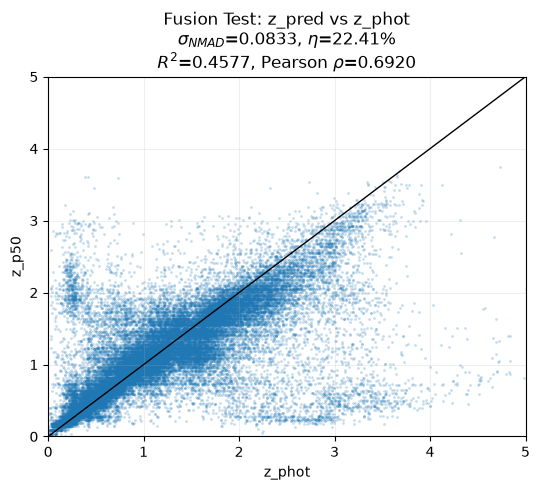

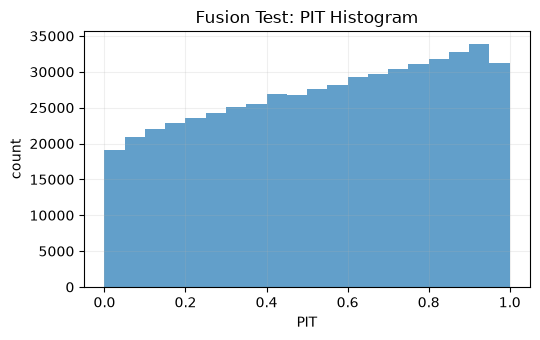

In [4]:
model_label = run["model_kind"].replace("_", " ").title()

fig, ax = am.plot_zpred_vs_zphot(
    test_eval,
    pred_key="z_p50",
    target_label="z_phot",
    title=f"{model_label} Test: z_pred vs z_phot",
    pmax=5.0,
    show_metrics=True,
)
fig.savefig("cnn_aion_clauds_test.jpeg", dpi=100)
plt.show()

fig, ax = am.plot_pit_histogram(
    test_eval,
    title=f"{model_label} Test: PIT Histogram",
)
plt.show()


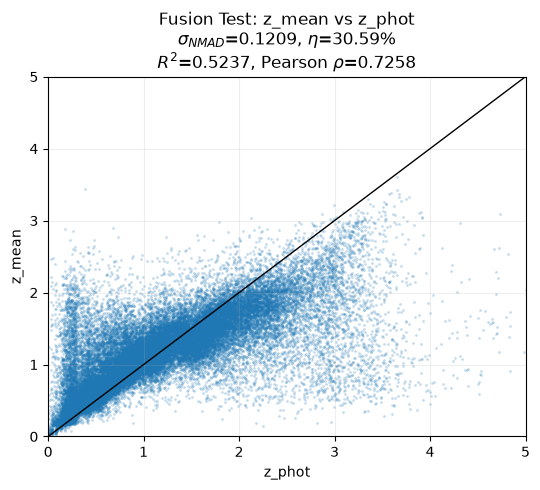

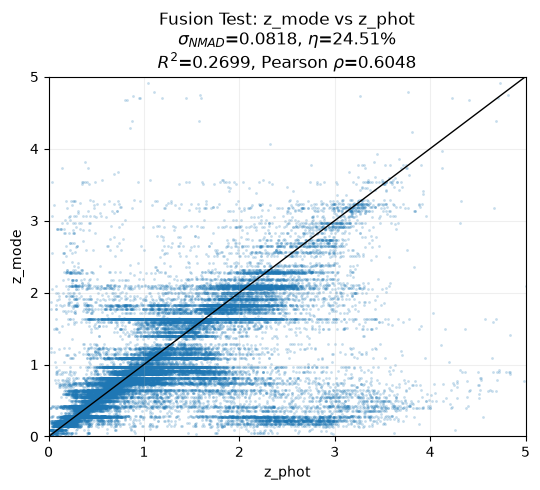

In [5]:
for pred_key in ["z_mean", "z_mode"]:
    fig, ax = am.plot_zpred_vs_zphot(
        test_eval,
        pred_key=pred_key,
        target_label="z_phot",
        title=f"{model_label} Test: {pred_key} vs z_phot",
        pmax=5.0,
        show_metrics=True,
    )
    plt.show()


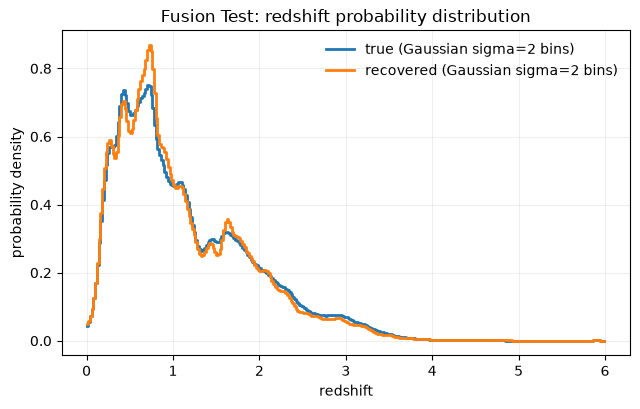

In [7]:
gaussian_sigma_bins = 2.0

fig, ax, pdf_data = am.plot_redshift_probability_distribution(
    test_eval,
    gaussian_sigma_bins=gaussian_sigma_bins,
    include_true=True,
    title=f"{model_label} Test: redshift probability distribution",
)
plt.show()


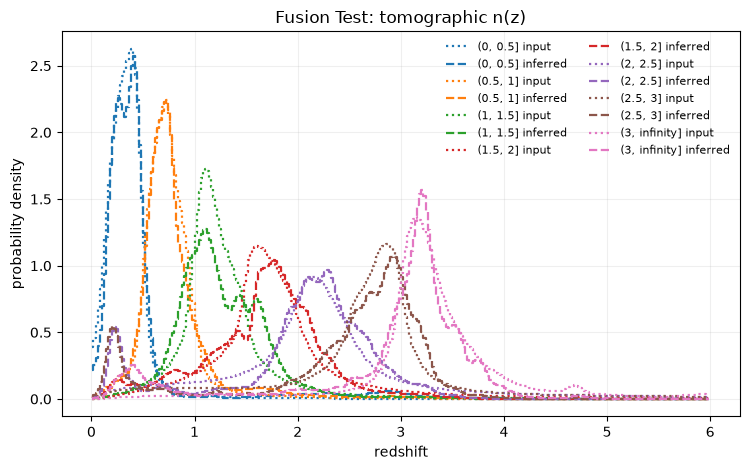

In [8]:
zphot_bin = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

fig, ax, nz_data = am.plot_nz_lensing_alike(
    test_eval,
    zphot_bin=zphot_bin,
    gaussian_sigma_bins=gaussian_sigma_bins,
    inferred_bin_key="z_p50",  # switch to "z_mean" or "z_mode" if desired
    n_samples_per_object=100,
    title=f"{model_label} Test: tomographic n(z)",
)
plt.savefig("tomo_experiment2.jpeg")


## Optional: compare two configs

Set `RUN_CONFIG_COMPARISON = True` when you want to train/evaluate both configs and render paired diagnostics.

In [2]:
EXTRA_BANDS1 = ()#"u", "u_star", "Y", "J", "H", "Ks")
USE_AION_EMBEDDING1 = True
USE_MLP_FEATURES1 = False
INCLUDE_GRIZY_IN_MLP1 = False  # None means: False with AION, True without AION.
AION_INPUT_BANDS1 = ("g", "r", "i", "z", "y")
AION_MAG_ADJUSTMENT_PATH1 = None
FORCE_RECOMPUTE_EMBEDDINGS1 = False

if not USE_MLP_FEATURES1:
    EVALUATE_MODEL_KIND1 = "aion"
    MODEL_KINDS1 = ("aion",)
elif USE_AION_EMBEDDING1:
    EVALUATE_MODEL_KIND1 = "fusion"
    MODEL_KINDS1 = ("tabular", "aion", "fusion")
else:
    EVALUATE_MODEL_KIND1 = "tabular"
    MODEL_KINDS1 = ("tabular",)

config_1 = am.AIONMagnitudeConfig(
    catalogue_path=Path("data/clauds/COSMOS-HSCpipe-Phosphoros.fits"),
    max_rows=None,
    force_recompute_embeddings=FORCE_RECOMPUTE_EMBEDDINGS1,
    z_min=0.0,
    z_max=6.0,
    n_z_bins=300,
    split_strategy="random",
    train_fraction=0.20,
    test_fraction=0.75,
    val_fraction=0.05,
    baseline_epochs=10,
    hsc_mag_faint_limits={"g": 24.5, "r": 24.5, "i": 24.0, "z": 24.5, "y": 24.5},
    extra_bands=EXTRA_BANDS1,
    extra_band_invalid_fill="median",
    extra_band_include_valid_flags=False,
    use_aion_embedding=USE_AION_EMBEDDING1,
    use_mlp_features=USE_MLP_FEATURES1,
    include_grizy_in_mlp=INCLUDE_GRIZY_IN_MLP1,
    aion_input_bands=AION_INPUT_BANDS1,
    aion_mag_adjustment_path=AION_MAG_ADJUSTMENT_PATH1,
    model_kinds=MODEL_KINDS1,
    device_choice="auto",
)

paths = am.resolve_training_paths(config_1)
paths


{'run_tag': 'COSMOS_HSCpipe_Phosphoros_zp23p0_all',
 'experiment_tag': 'COSMOS_HSCpipe_Phosphoros_zp23p0_all_aiononly',
 'split_output_dir': PosixPath('cache/clauds_split_COSMOS_HSCpipe_Phosphoros_zp23p0_all'),
 'cache_path': PosixPath('cache/clauds_aion_embeddings_COSMOS_HSCpipe_Phosphoros_zp23p0_all.pt'),
 'baseline_output_dir': PosixPath('cache/baselines_COSMOS_HSCpipe_Phosphoros_zp23p0_all_aiononly')}

In [3]:
RUN_CONFIG_COMPARISON = True

#config_1 = config

# Empty tuple means no extra u/u*/Y/J/H/Ks columns; with AION enabled and grizy not duplicated, this is AION-only.
EXTRA_BANDS2 = ()#"u", "u_star", "Y", "J", "H", "Ks")
USE_AION_EMBEDDING2 = False
USE_MLP_FEATURES2 = True
INCLUDE_GRIZY_IN_MLP2 = True
AION_INPUT_BANDS2 = ("g", "r", "i", "z", "y")
AION_MAG_ADJUSTMENT_PATH2 = None
FORCE_RECOMPUTE_EMBEDDINGS2 = False

if not USE_MLP_FEATURES2:
    EVALUATE_MODEL_KIND2 = "aion"
    MODEL_KINDS2 = ("aion",)
elif USE_AION_EMBEDDING2:
    EVALUATE_MODEL_KIND2 = "fusion"
    MODEL_KINDS2 = ("tabular", "aion", "fusion")
else:
    EVALUATE_MODEL_KIND2 = "tabular"
    MODEL_KINDS2 = ("tabular",)

config_2 = am.AIONMagnitudeConfig(
    catalogue_path=Path("data/clauds/COSMOS-HSCpipe-Phosphoros.fits"),
    max_rows=None,
    force_recompute_embeddings=FORCE_RECOMPUTE_EMBEDDINGS2,
    z_min=0.0,
    z_max=6.0,
    n_z_bins=300,
    split_strategy="random",
    train_fraction=0.20,
    test_fraction=0.75,
    val_fraction=0.05,
    baseline_epochs=10,
    hsc_mag_faint_limits={"g": 24.5, "r": 24.5, "i": 24.0, "z": 24.5, "y": 24.5},
    extra_bands=EXTRA_BANDS2,
    extra_band_invalid_fill="median",
    extra_band_include_valid_flags=False,
    use_aion_embedding=USE_AION_EMBEDDING2,
    use_mlp_features=USE_MLP_FEATURES2,
    include_grizy_in_mlp=INCLUDE_GRIZY_IN_MLP2,
    aion_input_bands=AION_INPUT_BANDS2,
    aion_mag_adjustment_path=AION_MAG_ADJUSTMENT_PATH2,
    model_kinds=MODEL_KINDS2,
    device_choice="auto",
)
comparison_labels = ("grizy-MLP-only", "grizy-aion-only")

if RUN_CONFIG_COMPARISON:
    '''
    run_2 = am.run_training_and_evaluation(
    config_2,
    model_kind=EVALUATE_MODEL_KIND2,
    split="test",
    )
    '''
    pair = am.run_config_pair(
        config_2,
        config_1,
        split="test",
    )
    
    eval_1 = pair["evaluation_1"]
    eval_2 = pair["evaluation_2"]
    '''
    eval_1 = run["evaluation"]
    eval_2 = run_2["evaluation"]
    '''

Starting embedding extraction and caching...


/Users/shiminggu/Documents/Science/aion_tutorial/aion_magnitude.py:3702: RuntimeWarning: Disabling individual HSC grizy bands is not currently supported because the frozen AION embedding expects the full grizy input; the requested AION band selection will be ignored for now.
  return build_and_cache_aion_embeddings(


Copied rows 0–250,000 / 5,474,883
Copied rows 250,000–500,000 / 5,474,883
Copied rows 500,000–750,000 / 5,474,883
Copied rows 750,000–1,000,000 / 5,474,883
Copied rows 1,000,000–1,250,000 / 5,474,883
Copied rows 1,250,000–1,500,000 / 5,474,883
Copied rows 1,500,000–1,750,000 / 5,474,883
Copied rows 1,750,000–2,000,000 / 5,474,883
Copied rows 2,000,000–2,250,000 / 5,474,883
Copied rows 2,250,000–2,500,000 / 5,474,883
Copied rows 2,500,000–2,750,000 / 5,474,883
Copied rows 2,750,000–3,000,000 / 5,474,883
Copied rows 3,000,000–3,250,000 / 5,474,883
Copied rows 3,250,000–3,500,000 / 5,474,883
Copied rows 3,500,000–3,750,000 / 5,474,883
Copied rows 3,750,000–4,000,000 / 5,474,883
Copied rows 4,000,000–4,250,000 / 5,474,883
Copied rows 4,250,000–4,500,000 / 5,474,883
Copied rows 4,500,000–4,750,000 / 5,474,883
Copied rows 4,750,000–5,000,000 / 5,474,883
Copied rows 5,000,000–5,250,000 / 5,474,883
Copied rows 5,250,000–5,474,883 / 5,474,883
Cached product loaded from: cache/clauds_noaion_cata

config.json:   0%|          | 0.00/1.75k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

codecs/z_cmodel_mag/model.safetensors:   0%|          | 0.00/404k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

codecs/y_cmodel_mag/model.safetensors:   0%|          | 0.00/404k [00:00<?, ?B/s]

Cached product loaded from: cache/clauds_aion_embeddings_COSMOS_HSCpipe_Phosphoros_zp23p0_all.pt
Metadata: {'catalogue_path': 'data/clauds/COSMOS-HSCpipe-Phosphoros.fits', 'split_output_dir': 'cache/clauds_split_COSMOS_HSCpipe_Phosphoros_zp23p0_all', 'max_rows': None, 'n_usable_rows': 723865, 'z_min': 0.0, 'z_max': 6.0, 'n_z_bins': 300, 'mag_zero_point': 23.0, 'hsc_mag_faint_limits': {'g': 24.5, 'r': 24.5, 'i': 24.0, 'z': 24.5, 'y': 24.5}, 'target_redshift_column': 'ZPHOT', 'redshift_reference_keys': ['z_high68', 'z_low68', 'z_peak', 'zphot'], 'feature_names': [], 'use_mlp_features': False, 'include_grizy_in_mlp': False, 'grizy_mlp_feature_names': [], 'extra_bands': [], 'extra_band_feature_names': [], 'aion_model': 'polymathic-ai/aion-base', 'aion_embedding_pooling': 'mean_encoder_tokens', 'embedding_batch_size': 512, 'use_aion_embedding': True, 'aion_input_bands': ['g', 'r', 'i', 'z', 'y'], 'split_strategy': 'random', 'split_fractions': {'train': 0.2, 'test': 0.75, 'val': 0.05}, 'spli

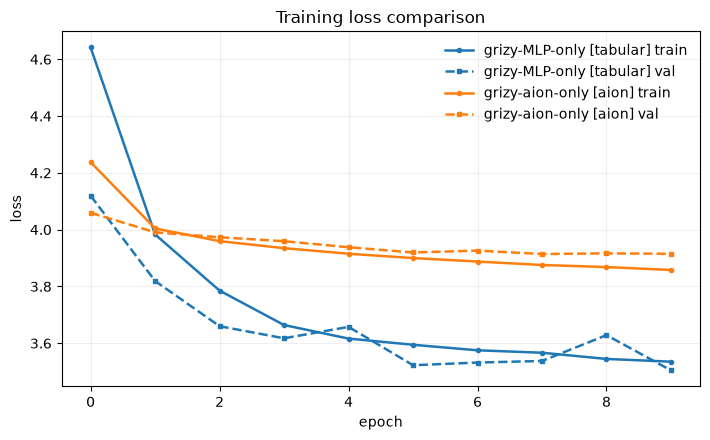

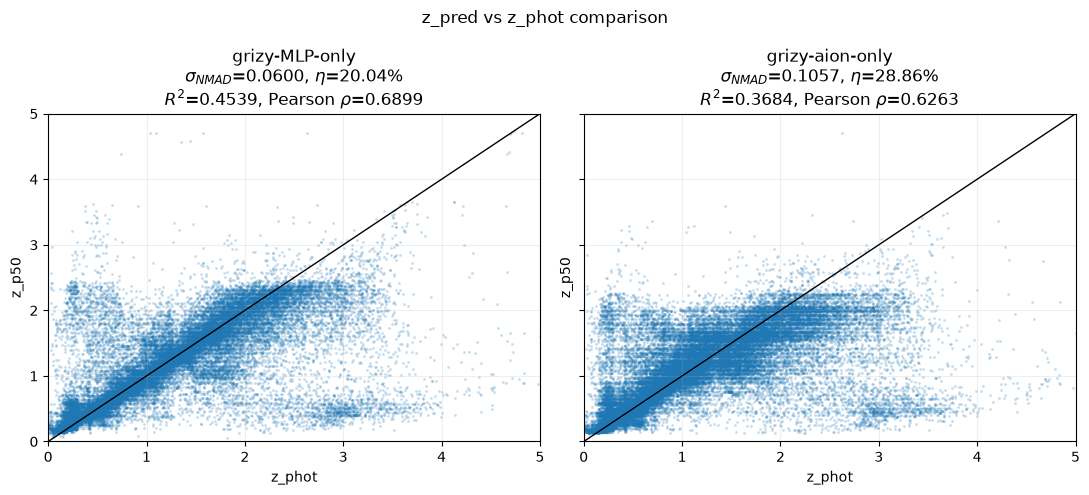

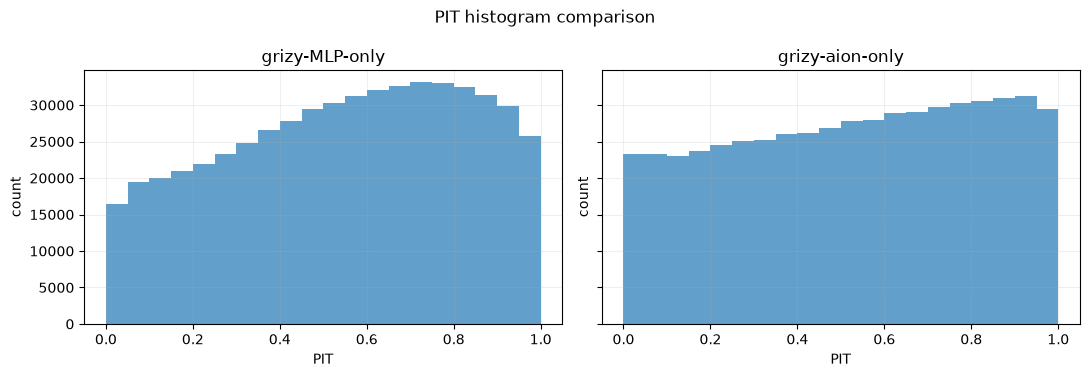

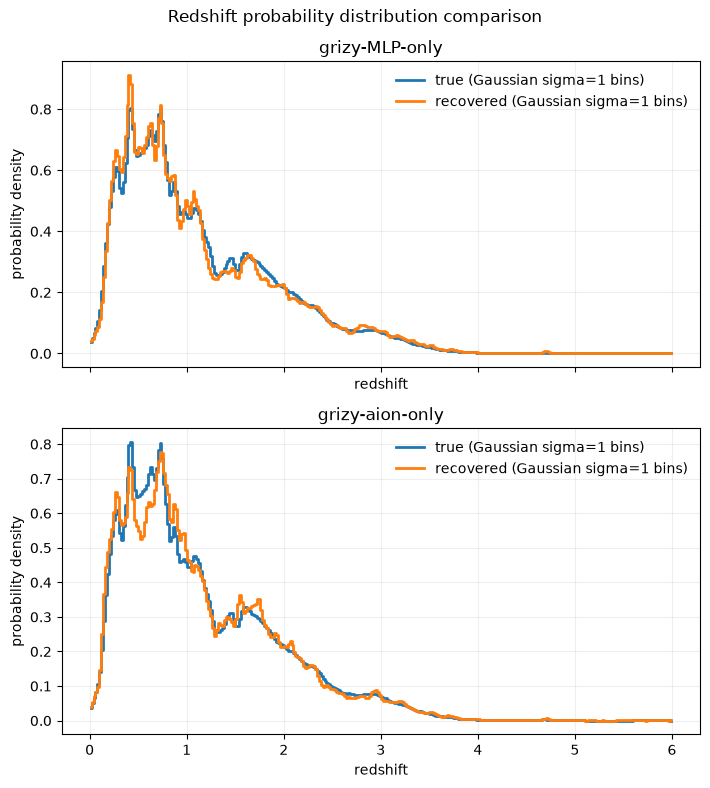

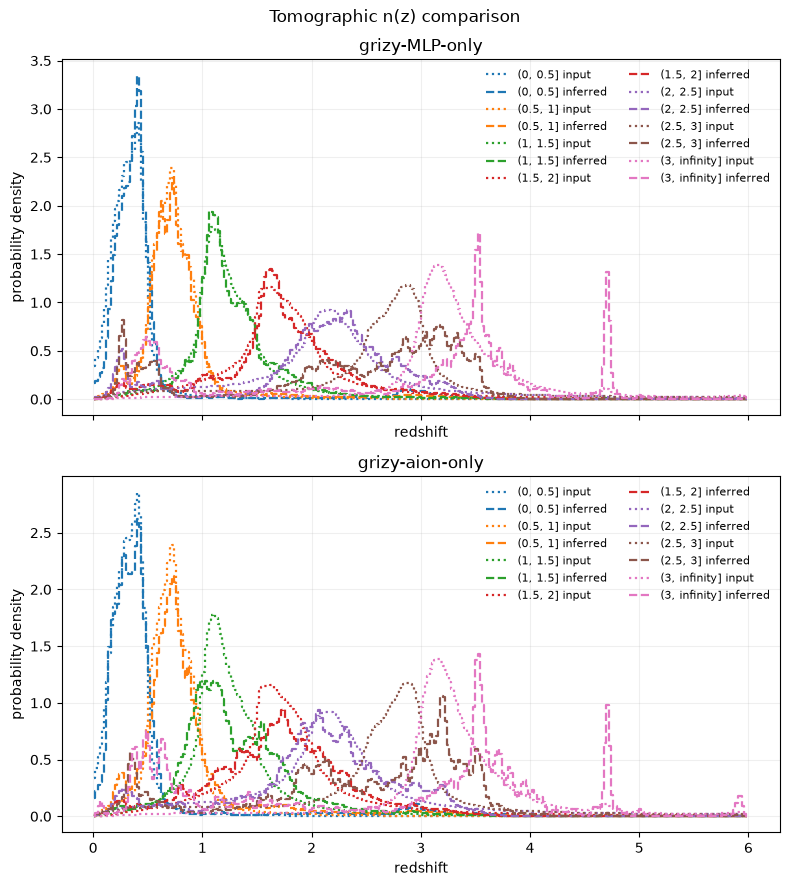

In [4]:
gaussian_sigma_bins = 1
zphot_bin = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
prefix = 'grizy_aion_mlp_comparison'
save_plot = True

if RUN_CONFIG_COMPARISON:
    fig, ax, loss_pair = am.compare_config_loss(
        pair,
        labels=comparison_labels,
    )
    plt.savefig(prefix+'_loss.jpeg', dpi=100)

    fig, axes = am.compare_zpred_vs_zphot(
        eval_1,
        eval_2,
        labels=comparison_labels,
        pred_key="z_p50",
        pmax=5.0,
        show_metrics=True,
    )
    if save_plot == True:
        plt.savefig(prefix+'_scatter.jpeg',dpi=100)

    fig, axes = am.compare_pit_histogram(
        eval_1,
        eval_2,
        labels=comparison_labels,
    )
    if save_plot == True:
        plt.savefig(prefix+'_pit.jpeg',dpi=100)

    fig, axes, pdf_pair = am.compare_redshift_probability_distribution(
        eval_1,
        eval_2,
        labels=comparison_labels,
        gaussian_sigma_bins=gaussian_sigma_bins,
    )
    if save_plot == True:
        plt.savefig(prefix+'_nz.jpeg',dpi=100)

    fig, axes, nz_pair = am.compare_nz_lensing_alike(
        eval_1,
        eval_2,
        labels=comparison_labels,
        zphot_bin=zphot_bin,
        gaussian_sigma_bins=gaussian_sigma_bins,
        inferred_bin_key="z_p50",
        n_samples_per_object=100,
    )
    if save_plot == True:
        plt.savefig(prefix+'_nztomo.jpeg',dpi=100)
